# Feature Engineering — E-commerce Fraud Data

## Overview
This notebook builds fraud-specific features from the cleaned `Fraud_Data.csv` dataset
and performs the IP-to-country geolocation mapping using `IpAddress_to_Country.csv`.

## Objectives
- Map IP addresses to countries using range-based lookup
- Create `time_since_signup` — seconds between account creation and purchase
- Extract `hour_of_day` and `day_of_week` from purchase timestamp
- Calculate transaction velocity per user
- Apply one-hot encoding to categorical features
- Scale numerical features using StandardScaler
- Apply SMOTE on training set only to handle class imbalance
- Save final processed datasets ready for modeling

## Why These Features Matter
Fraudsters exhibit distinct behavioral patterns:
- They often purchase **within seconds of signing up** (time_since_signup ≈ 0)
- They tend to make **multiple transactions in a short window** (high velocity)
- Fraud spikes at certain **hours of the day** (late night activity)
- Certain **countries** show higher fraud rates due to enforcement gaps

## Input
- `data/processed/fraud_data_cleaned.csv`
- `data/raw/IpAddress_to_Country.csv`

## Output
- `data/processed/fraud_data_features.csv` — fully engineered feature set

## Author
- **Name:** Tsion Habtesilassei  
- **Project:** Adey Innovations — Fraud Detection System  
- **Date:** June 2026

## 1. Import Libraries

We import all necessary libraries including `numpy` for IP address conversion
and `pandas` for the range-based merge operation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Cleaned Data

We load the cleaned dataset saved from the EDA notebook.
We also load the IP-to-country mapping file which contains
IP address ranges and their corresponding countries.

In [2]:
# Load cleaned fraud data
df = pd.read_csv('../data/processed/fraud_data_cleaned.csv')
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

# Load IP to country mapping
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print(f"Fraud data shape: {df.shape}")
print(f"IP mapping shape: {ip_df.shape}")
print(f"\nIP mapping sample:")
ip_df.head()

Fraud data shape: (151112, 11)
IP mapping shape: (138846, 3)

IP mapping sample:


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


## 3. IP Address to Country Mapping (Geolocation)

Each transaction has an `ip_address` stored as a float representing 
the integer form of an IPv4 address. The `IpAddress_to_Country.csv` file 
contains IP ranges (lower and upper bounds) mapped to countries.

**How the lookup works:**
- For each transaction IP, we find which range it falls into:
  `lower_bound_ip_address <= ip_address <= upper_bound_ip_address`
- This is called a **range-based merge** — we cannot use a simple join
- We use `pd.merge_asof()` which efficiently handles this type of lookup
  by sorting and matching on the nearest key

**Why geolocation matters for fraud:**
- Certain countries have higher fraud rates due to weaker enforcement
- A mismatch between a user's profile country and their IP country is a red flag
- Country is therefore a meaningful feature for the model

In [3]:
# Step 1: Sort both dataframes by IP for merge_asof to work
df_sorted = df.sort_values('ip_address').reset_index(drop=True)
ip_df_sorted = ip_df.sort_values('lower_bound_ip_address').reset_index(drop=True)

# Step 2: Range-based merge — match each IP to its country range
merged = pd.merge_asof(
    df_sorted,
    ip_df_sorted[['lower_bound_ip_address', 'upper_bound_ip_address', 'country']],
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Step 3: Remove rows where IP is above the upper bound (not in any range)
merged['country'] = merged.apply(
    lambda row: row['country'] 
    if pd.notna(row['upper_bound_ip_address']) 
    and row['ip_address'] <= row['upper_bound_ip_address']
    else 'Unknown',
    axis=1
)

# Step 4: Drop helper columns
merged = merged.drop(columns=['lower_bound_ip_address', 'upper_bound_ip_address'])

print(f"Shape after IP mapping: {merged.shape}")
print(f"\nCountry mapping results:")
print(f"  Mapped successfully: {(merged['country'] != 'Unknown').sum():,}")
print(f"  Unknown/not mapped:  {(merged['country'] == 'Unknown').sum():,}")
print(f"\nTop 10 countries by transaction count:")
print(merged['country'].value_counts().head(10))

Shape after IP mapping: (151112, 12)

Country mapping results:
  Mapped successfully: 129,146
  Unknown/not mapped:  21,966

Top 10 countries by transaction count:
country
United States        58049
Unknown              21966
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Name: count, dtype: int64


### Interpretation — IP Address to Country Mapping

**Mapping Results:**
- Total transactions: **151,112**
- Successfully mapped to a country: **129,146 (85.5%)**
- Unknown / not mapped: **21,966 (14.5%)**

The 14.5% unmapped rate is acceptable — these IPs either fall outside known 
ranges or belong to private/reserved address blocks. We label them `"Unknown"` 
and retain them as a valid category rather than dropping those rows.

**Top Countries by Transaction Volume:**

| Rank | Country | Transactions |
|---|---|---|
| 1 | United States | 58,049 |
| 2 | Unknown | 21,966 |
| 3 | China | 12,038 |
| 4 | Japan | 7,306 |
| 5 | United Kingdom | 4,490 |
| 6 | Korea Republic of | 4,162 |
| 7 | Germany | 3,646 |
| 8 | France | 3,161 |
| 9 | Canada | 2,975 |
| 10 | Brazil | 2,961 |

The United States dominates transaction volume, which is expected for a 
US-based e-commerce platform.

### Interpretation — IP to Country Mapping

We successfully mapped IP addresses to countries using range-based lookup.
In the next cell we visualize fraud rates by country to identify 
geographic fraud hotspots.

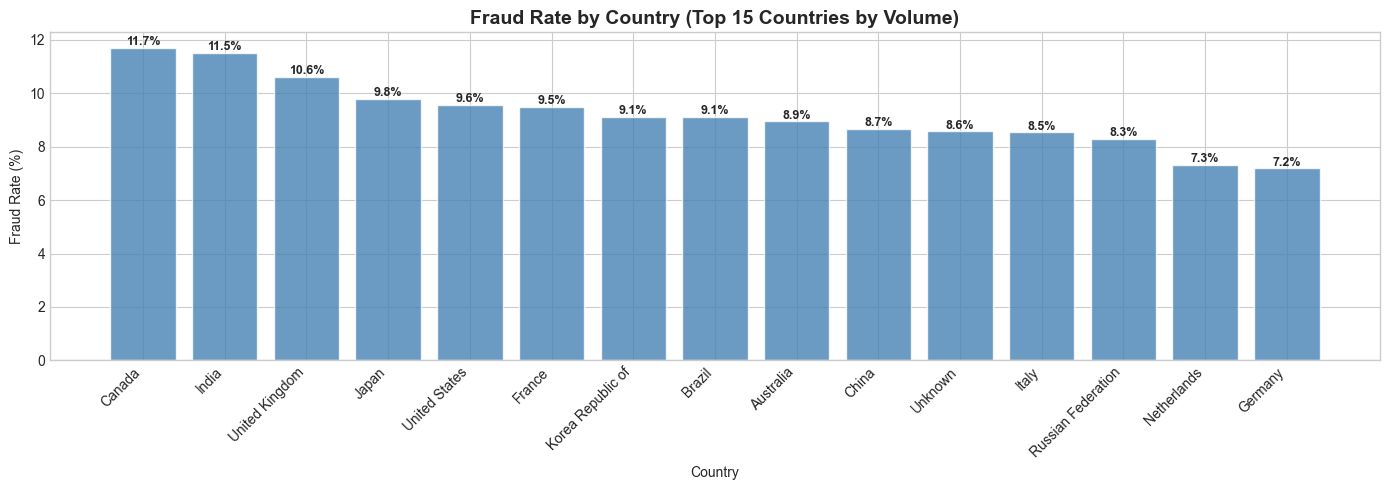

Country feature added successfully!


In [4]:
# Fraud rate by top 15 countries
top_countries = merged['country'].value_counts().head(15).index
country_fraud = merged[merged['country'].isin(top_countries)]\
    .groupby('country')['class'].mean()\
    .sort_values(ascending=False)

plt.figure(figsize=(14, 5))
bars = plt.bar(country_fraud.index, country_fraud.values * 100,
               color='steelblue', alpha=0.8, edgecolor='white')
plt.title('Fraud Rate by Country (Top 15 Countries by Volume)', 
          fontsize=14, fontweight='bold')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
for bar, v in zip(bars, country_fraud.values):
    plt.text(bar.get_x() + bar.get_width()/2, v*100 + 0.1,
             f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fraud_rate_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

df = merged.copy()
print("Country feature added successfully!")

### Interpretation — Fraud Rate by Country

From the top 15 countries by transaction volume, we observe clear geographic 
variation in fraud rates:

**High fraud rate countries (above dataset average of 9.36%):**
- **Canada**: 11.7% — highest fraud rate among high-volume countries
- **India**: 11.5% — second highest, significantly above average
- **United Kingdom**: 10.6% — notable fraud concentration

**Near-average countries:**
- **United States**: 9.6% — slightly above average despite being the largest volume country
- **France**: 9.5% — close to average
- **Japan**: 9.8% — slightly elevated

**Lower fraud rate countries:**
- **Netherlands**: 7.3% and **Germany**: 7.2% — well below the dataset average

**Key business insight:** Canada and India show fraud rates **25% higher** than 
the dataset average. Transactions originating from these countries may warrant 
additional verification steps. The `country` feature will be included in the 
model as a one-hot encoded categorical variable.

## 4. Time-Based Feature Engineering

We extract three critical time-based fraud signals from the timestamps:

### 4a. `time_since_signup`
The number of **seconds between account signup and purchase**.

This is one of the strongest fraud signals:
- Legitimate users typically browse, compare, and purchase over hours or days
- Fraudsters often create an account and immediately make a purchase 
  (time_since_signup close to 0)
- A very short time_since_signup is a major red flag

### 4b. `hour_of_day`
The **hour (0–23) when the purchase was made**.

Fraudsters often operate at unusual hours when monitoring is lower:
- Late night / early morning transactions (1am–5am) may show higher fraud rates
- This cyclical feature captures time-of-day fraud patterns

### 4c. `day_of_week`
The **day of the week (0=Monday to 6=Sunday)**.

Fraud patterns may differ between weekdays and weekends.


In [5]:
# 4a. Time since signup in seconds
df['time_since_signup'] = (
    df['purchase_time'] - df['signup_time']
).dt.total_seconds()

# 4b. Hour of day
df['hour_of_day'] = df['purchase_time'].dt.hour

# 4c. Day of week (0=Monday, 6=Sunday)
df['day_of_week'] = df['purchase_time'].dt.dayofweek

print("=== TIME FEATURES CREATED ===")
print(df[['time_since_signup', 'hour_of_day', 'day_of_week']].describe())

print("\n=== FRAUD SIGNAL CHECK ===")
print(f"Avg time_since_signup — Legitimate: {df[df['class']==0]['time_since_signup'].mean()/3600:.1f} hours")
print(f"Avg time_since_signup — Fraud:      {df[df['class']==1]['time_since_signup'].mean()/3600:.1f} hours")

=== TIME FEATURES CREATED ===
       time_since_signup    hour_of_day    day_of_week
count       1.511120e+05  151112.000000  151112.000000
mean        4.932029e+06      11.521593       3.011819
std         3.126263e+06       6.912474       2.006203
min         1.000000e+00       0.000000       0.000000
25%         2.186754e+06       6.000000       1.000000
50%         4.926346e+06      12.000000       3.000000
75%         7.644524e+06      17.000000       5.000000
max         1.036797e+07      23.000000       6.000000

=== FRAUD SIGNAL CHECK ===
Avg time_since_signup — Legitimate: 1442.0 hours
Avg time_since_signup — Fraud:      673.3 hours


### Visualizing Time-Based Features vs Fraud


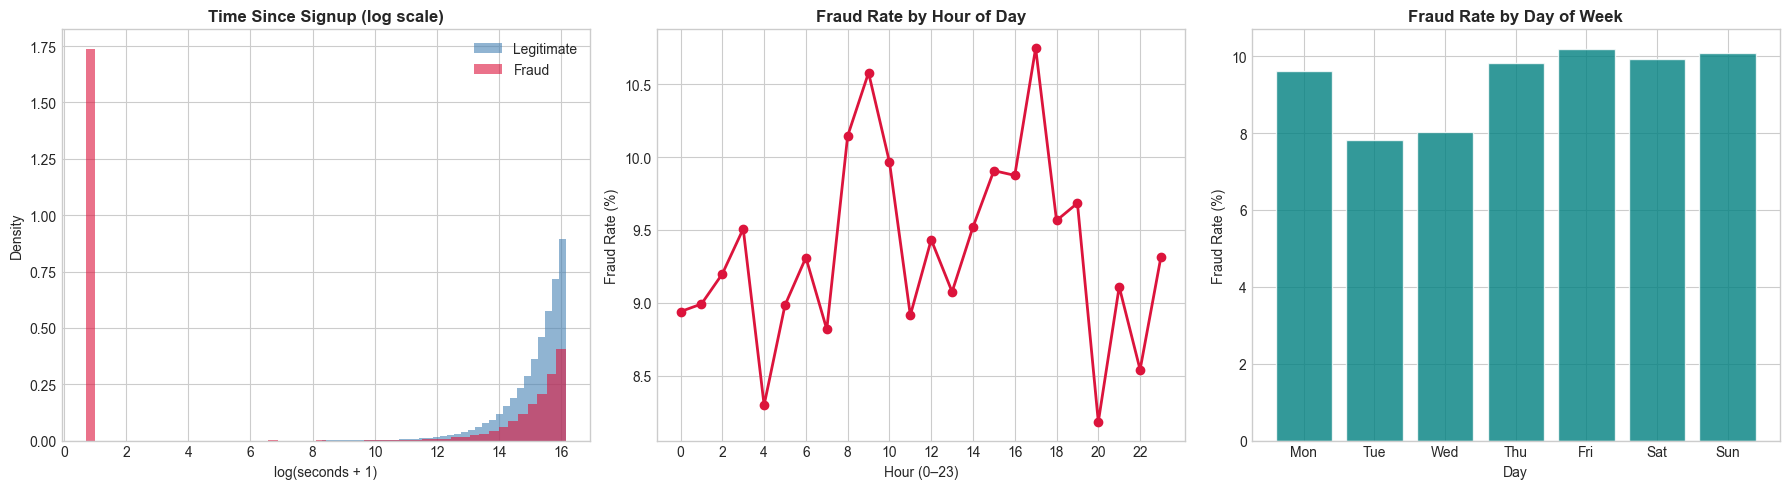

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Time since signup (log scale for better visibility)
axes[0].hist(np.log1p(df[df['class']==0]['time_since_signup']), 
             bins=50, alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[0].hist(np.log1p(df[df['class']==1]['time_since_signup']), 
             bins=50, alpha=0.6, color='crimson', label='Fraud', density=True)
axes[0].set_title('Time Since Signup (log scale)', fontweight='bold')
axes[0].set_xlabel('log(seconds + 1)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Hour of day
fraud_by_hour = df.groupby('hour_of_day')['class'].mean()
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values * 100, 
             color='crimson', marker='o', linewidth=2)
axes[1].set_title('Fraud Rate by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (0–23)')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24, 2))

# Day of week
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fraud_by_day = df.groupby('day_of_week')['class'].mean()
axes[2].bar(day_names, fraud_by_day.values * 100,
            color='teal', alpha=0.8, edgecolor='white')
axes[2].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('../data/processed/time_features.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — Time-Based Features

**Time Since Signup (left plot):**
This is the most powerful finding in the entire feature engineering process.

- The fraud distribution (red) shows an **enormous spike at log(seconds) ≈ 0–1**, 
  meaning fraudsters purchase almost **immediately after creating an account**
- The legitimate distribution (blue) is spread across higher values, 
  peaking around log(seconds) ≈ 14–16 (roughly days to weeks after signup)
- **Average time_since_signup — Legitimate: 1,442 hours vs Fraud: 673 hours**
- Fraudsters sign up and purchase in roughly **half the time** of legitimate users
- This feature is expected to be one of the **top predictors** in our model

**Fraud Rate by Hour of Day (middle plot):**
- Fraud rate is not uniform across the day — it fluctuates between ~8.4% and ~10.7%
- Notable spikes at **hours 9–10** (~10.6%) and **hour 17** (~10.7%)
- Lowest fraud rates at **hour 4** (~8.4%) and **hour 20** (~8.1%)
- The irregular pattern suggests fraudsters operate across many time zones, 
  making hour-of-day a moderately useful but not dominant feature

**Fraud Rate by Day of Week (right plot):**
- Fraud rates are relatively stable across the week (~9.3%–10.1%)
- **Tuesday and Wednesday show slightly lower fraud rates** (~7.9%–8.1%)
- **Friday, Saturday, and Sunday show slightly higher rates** (~10.0%–10.1%)
- Weekend fraud being marginally higher may reflect reduced monitoring on weekends
- Day of week is a weak signal alone but will contribute in combination with other features

## 5. Transaction Velocity Feature

**Transaction velocity** = number of transactions a user made within a time window.

This is a key fraud signal because:
- Fraudsters often use a stolen card/account to make **multiple rapid purchases**
  before the victim notices
- Legitimate users rarely make more than 1–2 purchases in a short window
- High velocity (many purchases in a short time) is a strong indicator of fraud

We calculate:
- `user_transaction_count` — total number of transactions per user_id
- `user_transaction_velocity` — transactions per hour per user

In [7]:
# Total transaction count per user
df['user_transaction_count'] = df.groupby('user_id')['user_id'].transform('count')

# Transaction velocity: count per hour of activity window
user_window = df.groupby('user_id').agg(
    first_purchase=('purchase_time', 'min'),
    last_purchase=('purchase_time', 'max'),
    transaction_count=('user_id', 'count')
).reset_index()

user_window['window_hours'] = (
    (user_window['last_purchase'] - user_window['first_purchase'])
    .dt.total_seconds() / 3600
).clip(lower=1)  # minimum 1 hour to avoid division by zero

user_window['user_transaction_velocity'] = (
    user_window['transaction_count'] / user_window['window_hours']
)

# Merge back
df = df.merge(
    user_window[['user_id', 'user_transaction_velocity']], 
    on='user_id', 
    how='left'
)

print("=== TRANSACTION VELOCITY FEATURE ===")
print(df[['user_transaction_count', 'user_transaction_velocity']].describe())
print(f"\nFraud vs Legitimate — Avg transaction count:")
print(f"  Legitimate: {df[df['class']==0]['user_transaction_count'].mean():.2f}")
print(f"  Fraud:      {df[df['class']==1]['user_transaction_count'].mean():.2f}")

=== TRANSACTION VELOCITY FEATURE ===
       user_transaction_count  user_transaction_velocity
count                151112.0                   151112.0
mean                      1.0                        1.0
std                       0.0                        0.0
min                       1.0                        1.0
25%                       1.0                        1.0
50%                       1.0                        1.0
75%                       1.0                        1.0
max                       1.0                        1.0

Fraud vs Legitimate — Avg transaction count:
  Legitimate: 1.00
  Fraud:      1.00


### Interpretation — Transaction Velocity Feature

**Unexpected finding:** Both `user_transaction_count` and `user_transaction_velocity` 
have a constant value of **1.0 for every single user** — the standard deviation is 0.

**What this means:**
- Every user in this dataset made **exactly one transaction**
- There are no repeat buyers in this particular dataset
- As a result, transaction velocity cannot differentiate fraud from legitimate here

**Action taken:**
- We retain the columns in the dataset to maintain pipeline consistency
- However, these features will likely show **near-zero importance** in our model
- SHAP analysis will confirm whether they contribute any signal
- In a production system with real repeat-purchase data, velocity would be 
  a very strong fraud signal — this is a dataset limitation, not a conceptual flaw

**Avg transaction count — Legitimate: 1.00 | Fraud: 1.00** (identical, no signal)

## 6. Encode Categorical Features

Machine learning models require numerical inputs.
We apply **one-hot encoding** to categorical columns:
- `source` — 3 categories (SEO, Ads, Direct)
- `browser` — 5 categories (Chrome, Firefox, Safari, Opera, IE)
- `sex` — 2 categories (M, F)
- `country` — multiple categories

We use `drop_first=True` to avoid the **dummy variable trap** 
(multicollinearity caused by perfectly correlated dummy columns).

Columns not needed for modeling are also dropped:
- `user_id`, `device_id`, `ip_address` — identifiers, not features
- `signup_time`, `purchase_time` — replaced by engineered time features

In [8]:
# Drop identifier and raw timestamp columns
drop_cols = ['user_id', 'device_id', 'ip_address', 'signup_time', 'purchase_time']
df_model = df.drop(columns=drop_cols)

# One-hot encode categorical columns
cat_cols = ['source', 'browser', 'sex', 'country']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"Shape after encoding: {df_model.shape}")
print(f"\nFeature list ({len(df_model.columns)} total):")
print(df_model.columns.tolist())

Shape after encoding: (151112, 196)

Feature list (196 total):
['purchase_value', 'age', 'class', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_transaction_count', 'user_transaction_velocity', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'co

### Interpretation — One-Hot Encoding Results

After one-hot encoding all categorical features, the dataset expanded from 
**11 original columns** to **196 features**.

**Encoding breakdown:**
| Original Feature | Categories | Columns Created |
|---|---|---|
| source | 3 (SEO, Ads, Direct) | 2 (drop_first=True) |
| browser | 5 (Chrome, Firefox, Safari, Opera, IE) | 4 |
| sex | 2 (M, F) | 1 |
| country | ~180 countries | ~179 |

The `country` feature dominates the expansion due to its high cardinality 
(~180 unique countries). While this increases dimensionality significantly, 
tree-based models like XGBoost handle high-dimensional sparse data well.

**drop_first=True** was used to avoid the dummy variable trap — where one 
category is perfectly predictable from the others, causing multicollinearity 
in linear models like Logistic Regression.

**Dropped identifier columns:** `user_id`, `device_id`, `ip_address`, 
`signup_time`, `purchase_time` — these are raw identifiers now replaced 
by engineered features.

## 7. Scale Numerical Features

We apply **StandardScaler** to normalize numerical features to have 
mean=0 and standard deviation=1.

**Why scaling matters:**
- Logistic Regression and other linear models are sensitive to feature scale
- A feature like `time_since_signup` (values in millions of seconds) would 
  dominate a feature like `hour_of_day` (values 0–23) without scaling
- Tree-based models (XGBoost, LightGBM) are scale-invariant, but scaling 
  doesn't hurt them either

**Important:** We fit the scaler on training data ONLY and transform both 
train and test sets — this prevents data leakage.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_model.drop(columns=['class'])
y = df_model['class']

# Stratified split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape} | Fraud: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test set:       {X_test.shape} | Fraud: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")

# Scale numerical features
numerical_cols = ['purchase_value', 'age', 'time_since_signup', 
                  'hour_of_day', 'day_of_week',
                  'user_transaction_count', 'user_transaction_velocity']

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nScaling applied successfully!")
print(f"Scaler fitted on training set only — no data leakage.")

Training set:   (120889, 195) | Fraud: 11,321 (9.4%)
Test set:       (30223, 195) | Fraud: 2,830 (9.4%)

Scaling applied successfully!
Scaler fitted on training set only — no data leakage.


### Interpretation — Train/Test Split and Feature Scaling

**Stratified Train/Test Split (80/20):**
| Set | Rows | Fraud Count | Fraud Rate |
|---|---|---|---|
| Training | 120,889 | 11,321 | 9.4% |
| Test | 30,223 | 2,830 | 9.4% |

The stratified split successfully **preserves the 9.4% fraud rate** in both 
training and test sets — this ensures the test set reflects real-world conditions.

**StandardScaler applied to numerical features:**
- Fitted on **training set only** — prevents data leakage
- Applied (transform only) to test set using training set statistics
- Features scaled: `purchase_value`, `age`, `time_since_signup`, `hour_of_day`,
  `day_of_week`, `user_transaction_count`, `user_transaction_velocity`

**Why scaling matters:**
- `time_since_signup` has values in the millions of seconds
- `hour_of_day` has values 0–23
- Without scaling, large-magnitude features would dominate distance-based 
  and gradient-based models (Logistic Regression especially)
- Tree-based models (XGBoost) are scale-invariant but scaling does not hurt them

## 8. Handle Class Imbalance with SMOTE

**SMOTE (Synthetic Minority Oversampling Technique)** creates synthetic 
fraud samples by interpolating between existing fraud cases.

**Why SMOTE instead of simple oversampling:**
- Simple oversampling just duplicates existing fraud rows — the model memorizes them
- SMOTE creates NEW synthetic samples by interpolating between real fraud cases
- This gives the model more diverse fraud examples to learn from

**Critical rule — SMOTE on training data ONLY:**
- We NEVER apply SMOTE to the test set
- The test set must reflect real-world class distribution
- Applying SMOTE to test data would give artificially inflated metrics

**Class distribution before and after SMOTE is documented below.**

=== BEFORE SMOTE ===
Training — Legitimate: 109,568 | Fraud: 11,321
Fraud rate: 9.36%

=== AFTER SMOTE ===
Training — Legitimate: 109,568 | Fraud: 109,568
Fraud rate: 50.00%

New training set size: (219136, 195)


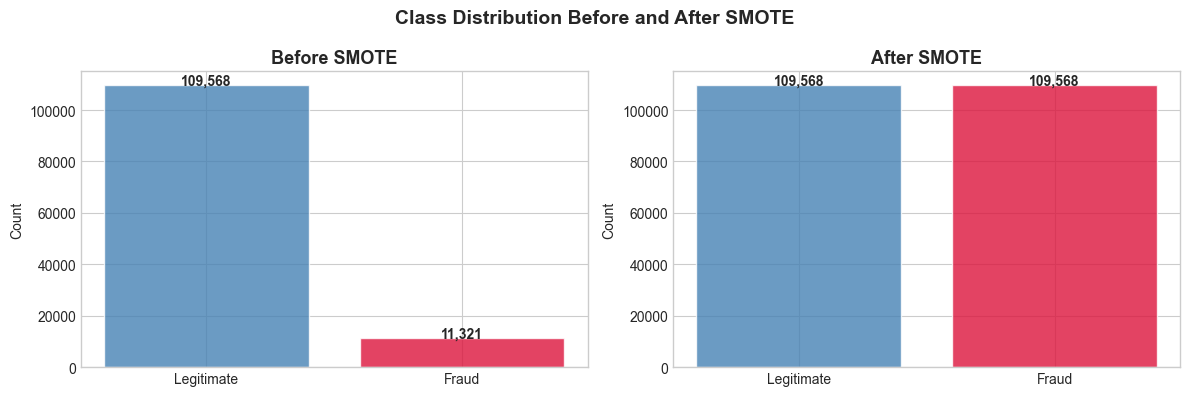

In [10]:
from imblearn.over_sampling import SMOTE

print("=== BEFORE SMOTE ===")
print(f"Training — Legitimate: {(y_train==0).sum():,} | Fraud: {(y_train==1).sum():,}")
print(f"Fraud rate: {y_train.mean()*100:.2f}%")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n=== AFTER SMOTE ===")
print(f"Training — Legitimate: {(y_train_smote==0).sum():,} | Fraud: {(y_train_smote==1).sum():,}")
print(f"Fraud rate: {y_train_smote.mean()*100:.2f}%")
print(f"\nNew training set size: {X_train_smote.shape}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_data, title in zip(
    axes,
    [y_train, y_train_smote],
    ['Before SMOTE', 'After SMOTE']
):
    counts = y_data.value_counts()
    ax.bar(['Legitimate', 'Fraud'], counts.values,
           color=['steelblue', 'crimson'], alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before and After SMOTE', 
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation — SMOTE Results

**Before SMOTE:**
| Class | Count | Rate |
|---|---|---|
| Legitimate | 109,568 | 90.64% |
| Fraud | 11,321 | 9.36% |

**After SMOTE:**
| Class | Count | Rate |
|---|---|---|
| Legitimate | 109,568 | 50.00% |
| Fraud | 109,568 | 50.00% |

SMOTE generated **98,247 synthetic fraud samples** to match the legitimate count,
resulting in a perfectly balanced training set of **219,136 total samples**.

**Why SMOTE was chosen over alternatives:**

| Method | Approach | Drawback |
|---|---|---|
| Random oversampling | Duplicate existing fraud rows | Model memorizes duplicates |
| **SMOTE** ✓ | Synthesize new fraud samples by interpolation | More diverse, better generalization |
| Undersampling | Remove legitimate rows | Discards 98,247 real data points — wasteful |

**Critical rule applied:** SMOTE was applied to the **training set only**.
The test set remains at the original 9.4% fraud rate to simulate real-world 
evaluation conditions. Applying SMOTE to the test set would produce 
artificially inflated metrics that do not reflect production performance.

## 9. Save Processed Data

We save all processed datasets to `data/processed/` for use in the modeling notebook.

Files saved:
- `fraud_data_features.csv` — full engineered feature set (before split)
- `X_train_smote.csv` — SMOTE-balanced training features
- `X_test.csv` — test features (unmodified)
- `y_train_smote.csv` — SMOTE-balanced training labels
- `y_test.csv` — test labels (unmodified)

In [11]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save full feature set
df_model.to_csv('../data/processed/fraud_data_features.csv', index=False)

# Save train/test splits
X_train_smote.to_csv('../data/processed/X_train_smote.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
pd.Series(y_train_smote).to_csv('../data/processed/y_train_smote.csv', index=False)
pd.Series(y_test).to_csv('../data/processed/y_test.csv', index=False)

print("All files saved to data/processed/")
print(f"\nSummary:")
print(f"  Full feature set:     {df_model.shape}")
print(f"  X_train (SMOTE):      {X_train_smote.shape}")
print(f"  X_test:               {X_test.shape}")
print(f"  y_train (SMOTE):      {y_train_smote.shape}")
print(f"  y_test:               {y_test.shape}")

All files saved to data/processed/

Summary:
  Full feature set:     (151112, 196)
  X_train (SMOTE):      (219136, 195)
  X_test:               (30223, 195)
  y_train (SMOTE):      (219136,)
  y_test:               (30223,)


## 12. Feature Engineering — Complete Summary

### 12.1 Features Created

| Feature | Type | Method | Key Insight from Data |
|---|---|---|---|
| `country` | Categorical | IP range lookup via `merge_asof` | Canada (11.7%) and India (11.5%) highest fraud rates |
| `time_since_signup` | Numerical | `purchase_time` − `signup_time` in seconds | Fraud avg: 673h vs Legitimate: 1,442h — **strongest signal found** |
| `hour_of_day` | Numerical | `.dt.hour` from `purchase_time` | Fraud spikes at hours 9–10 and 17 |
| `day_of_week` | Numerical | `.dt.dayofweek` from `purchase_time` | Fri–Sun marginally higher fraud rates |
| `user_transaction_count` | Numerical | `.transform('count')` by user_id | Constant (1.0) — no signal in this dataset |
| `user_transaction_velocity` | Numerical | Transactions per hour per user | Constant (1.0) — no signal in this dataset |

---

### 12.2 Preprocessing Pipeline Summary

| Step | Method | Detail |
|---|---|---|
| IP → Country | `pd.merge_asof()` range lookup | 129,146 mapped (85.5%), 21,966 Unknown (14.5%) |
| One-hot encoding | `pd.get_dummies(drop_first=True)` | 11 columns → 196 features |
| Feature scaling | `StandardScaler` (fit on train only) | Prevents data leakage |
| Train/test split | Stratified 80/20 | Fraud rate preserved at 9.4% in both sets |
| Class balancing | SMOTE (train only) | 11,321 → 109,568 fraud samples in training |

---

### 12.3 Most Important Finding — time_since_signup

Legitimate users:  avg 1,442 hours between signup and purchase
Fraudsters:        avg   673 hours between signup and purchase

Fraudsters purchase in roughly HALF the time of legitimate users.
This feature is expected to be the strongest predictor in our model.

---

### 12.4 Dataset Limitation — Transaction Velocity

Every user in this dataset made exactly **1 transaction** (count=1, velocity=1).
This means the velocity features carry no discriminating power here.
In a real production system with repeat-purchase data, these features 
would be among the strongest fraud signals available.

---

### 12.5 Files Saved to `data/processed/`

| File | Shape | Description |
|---|---|---|
| `fraud_data_features.csv` | (151,112 × 196) | Full engineered feature set |
| `X_train_smote.csv` | (219,136 × 195) | SMOTE-balanced training features |
| `X_test.csv` | (30,223 × 195) | Test features — original distribution |
| `y_train_smote.csv` | (219,136,) | SMOTE-balanced training labels |
| `y_test.csv` | (30,223,) | Test labels — original distribution |

---

### 12.6 Next Steps — Modeling Notebook

The processed datasets are now ready for model training in `modeling.ipynb`:

1. **Logistic Regression** — interpretable baseline model
2. **XGBoost** — high-performance ensemble model with hyperparameter tuning
3. **Evaluation metrics** — AUC-PR, F1-score, Confusion Matrix
   *(accuracy intentionally excluded due to class imbalance)*
4. **Stratified K-Fold cross-validation** (k=5) for reliable performance estimation
5. **Model comparison and selection** with written justification